<a href="https://colab.research.google.com/github/shown5/Hands-on-Generative-AI/blob/main/chap5_StableDiffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

５章 Stable Diffusion と条件付き生成

前章までで画像の生成はできるようになったが、モデルの訓練には時間がかかり、生成される画像を制御することはできなかった。
本章ではより発展的に、テキストの説明に基づいて効率的に画像を生成できる、テキスト条件付きモデルへと発展させる方法を、Stable Diffusion を事例として見ていく。

その前に、まず条件付きモデルがどのように動作するかを確認し、現在のテキストから画像への生成モデルにつながる技術革新について振り返る。

5.1 制御の追加：条件付き拡散モデル

モデルの出力を制御する方法の一つに**条件付け**がある。
これはモデルに対して「どんな画像でも良い」とするのではなく、「あらかじめ決められたクラスに属する画像を生成せよ」と指示を与えるもの。
生成の過程でラベルやプロンプトなどの追加情報を与え、モデルの出力を誘導することを指す。

データセットは前章の蝶の画像の代わりに、画像にクラスラベルが付与された衣服画像のデータセットを用いる。
ポイントは、画像に加えて、画像が属するクラスラベルも入力に用いる点。
これによりモデルが画像とラベルの間の関連性を学び、特徴を理解できるようになることを期待する。

分類問題を解決することを目的としていない点に注意。
目的は前章と同じく、使用するデータセットから生成されたような最もらしい画像を生成させたいということ。
訓練の方法や損失関数は前章と同じものを使う。なぜなら本質的には本章でも同じタスクだから。

5.1.1 データの準備

今回は Fashion MNIST を使う。

In [1]:
%pip install genaibook

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.2 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
  Attempting uninstall: huggingface_hub
    Found e

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…):   0%|          | 0.00/30.9M [00:00<?, ?B/s]

fashion_mnist/test-00000-of-00001.parque(…):   0%|          | 0.00/5.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

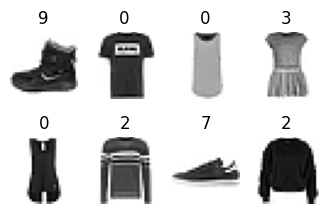

In [2]:
import matplotlib as mpl
from datasets import load_dataset

from genaibook.core import show_images

mpl.rcParams["image.cmap"] = "gray_r"

fashion_mnist = load_dataset("fashion_mnist")
clothes = fashion_mnist["train"]["image"][:8]
classes = fashion_mnist["train"]["label"][:8]
show_images(clothes, titles=classes, figsize=(4, 2.5))

今回は画像を 32 * 32 ピクセルにパディングする。

In [2]:
import torch
from torchvision import transforms

preprocess = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Pad(2),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)

def transform(examples):
  images = [preprocess(image) for image in examples["image"]]
  return {"images": images, "labels": examples["label"]}


train_dataset = fashion_mnist["train"].with_transform(transform)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=256, shuffle=True
)

NameError: name 'fashion_mnist' is not defined

5.1.2 クラス条件付きモデルの作成

UNet はカスタムの条件付け情報を与えることができる。
コンストラクタに num_class_embeds を追加するだけ。
Fashion MNIST のクラスすうが１０個なので、この引数に渡す値も１０とする。

In [4]:
from diffusers import UNet2DModel

model = UNet2DModel(
    in_channels=1,
    out_channels=1,
    sample_size=32,
    block_out_channels=(32, 64, 128, 256),
    num_class_embeds=10
)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


このモデルで予測を行うには forward() メソッドにクラスラベルを追加で渡す必要がある

In [5]:
x = torch.randn((1, 1, 32, 32))
with torch.inference_mode():
  out = model(x, timestep=7, class_labels=torch.tensor([2])).sample
out.shape

torch.Size([1, 1, 32, 32])

5.1.3 モデルの訓練

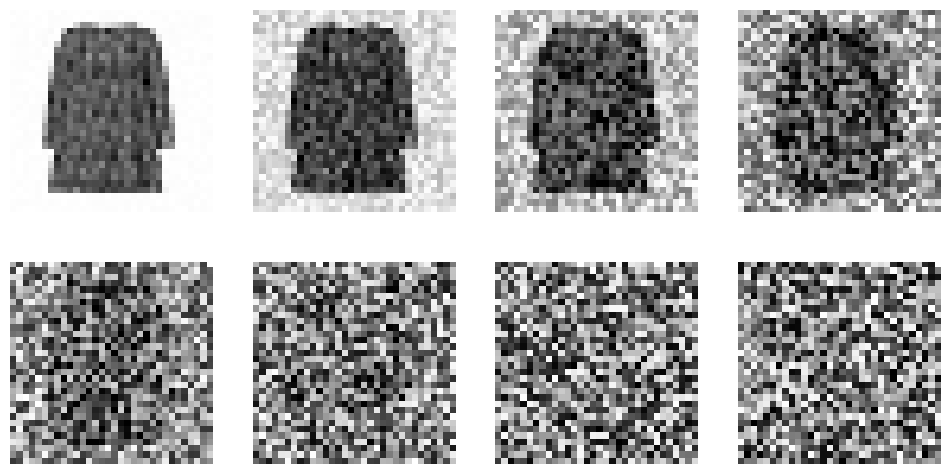

In [6]:
from diffusers import DDPMScheduler

scheduler = DDPMScheduler(
    num_train_timesteps=1000, beta_start=0.001, beta_end=0.02
)
timesteps = torch.linspace(0, 999, 8).long()
batch = next(iter(train_dataloader))

# データセットから８名の画像を読み込みノイズの量を徐々に増やしていく
x = batch["images"][0].expand([8, 1, 32, 32])
noise = torch.rand_like(x)
noised_x = scheduler.add_noise(x, noise, timesteps)
show_images((noised_x * 0.5 + 0.5).clip(0, 1))

In [ ]:
from torch.nn import functional as F
from tqdm import tqdm

from genaibook.core import get_device

#スケジューラー初期化
schedeler = DDPMScheduler(
    num_train_timesteps=1000, beta_start=0.0001, beta_end=0.02
)

num_epochs = 25
lr = 3e-4 #学習率
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, eps=1e-5)
losses = [] #後で表示するために損失を保存しておくリスト

device = get_device()
model = model.to(device)

#モデルを訓練する（時間かかる）
for epoch in (progress := tqdm(range(num_epochs))):
  for step, batch in(
      inner := tqdm(
          enumerate(train_dataloader),
          position=0,
          leave=True,
          total=len(train_dataloader)
      )
  ):
    #入力画像とクラスを読み込む
    clean_images = batch["images"].to(device)
    class_labels = batch["labels"].to(device)

    #画像に加えるノイズをサンプリングする
    noise = torch.randn(clean_images.shape).to(device)

    #各画像ごとにランダムなタイムステップをサンプリングする
    timesteps = torch.randint(
        0,
        scheduler.config.num_train_timesteps,
        (clean_images.shape[0],),
        device=device
    ).long()

    #タイムステップごとのノイズ量に従って画像にノイズを加える
    noisy_images = scheduler.add_noise(clean_images, noise, timesteps)

    #ノイズに対するモデルの予測値を得る
    #モデルにクラスラベルを渡している点に注目
    noise_pred = model(noisy_images, timesteps, class_labels=class_labels, return_dict=False)[0]

    #予測値と実際のノイズを比較する
    loss = F.mse_loss(noise_pred, noise)

    # 損失を更新し、表示する
    inner.set_postfix(loss=f"{loss.cpu().item():.3f}")

    #後で表示できるように損失を保存する
    losses.append(loss.item())

    #この損失に基づきモデルのパラメーターを更新する
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

 18%|█▊        | 42/235 [00:31<02:24,  1.34it/s, loss=0.028]

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses)

5.1.4 サンプリング

これで任意の画像とラベルを受け取って予測を実行するモデルができた。
ランダムノイズから開始し任意のクラスラベルを指定して繰り返しノイズ除去を行うことで好きなクラスのサンプル画像を生成できる。

In [ ]:
def generate_from_class(class_to_generate, n_samples=8):
  sample = torch.randn(n_samples, 1, 32, 32).to(device)
  class_labels = [class_to_generate] * n_samples
  class_labels = torch.tensor(class_labels).to(device)

  for _, t in tqdm(enumerate(scheduler.timesteps)):
    # モデルによる予測値を得る
    with torch.inference_mode():
      noise_pred = model(sample, t, class_labels=class_labels).sample

    # ステップごとにサンプルを更新する
    sample = scheduler.step(noise_pred, t, sample).prev_sample

  return sample.clip(-1, 1) * 0.5 + 0,5

In [ ]:
# 試しに Tシャツの画像（クラス０）を生成してみる
images = generate_from_class(0)
show_images(images, nrows=2)

In [ ]:
# スニーカー（クラス７）も生成してみる
images = generate_from_class(7)
show_images(images, nrows=2)

In [ ]:
# 最後にブーツ（クラス９）も生成してみる
images = generate_from_class(9)
show_images(images, nrows=2)

5.2 潜在拡散による効率化の向上

これで条件付きモデルの訓練が可能になったので、あとはスケールを大きくすればいいかと思いきや、そんな単純な話ではない。
画像サイズが大きくなるにつれて、計算量も急激に増加する。特にセルフアテンションを使用した場合に顕著で、入力量が増えると計算量は２乗に比例して増加する。

潜在拡散はこの問題を解消するために、別途用意した変分オートエンコーダー（VAE）をを活用する。
VAE を用いて入力画像を８分の１にまで圧縮し入力に渡すようにする。

これが Stable Diffusion である。

5.3 Stable Diffusion の構成要素

Stable Diffusion はテキストプロンプトに基づいて画像を生成できる潜在拡散モデル。
専門的な知識がなくても Stable Diffusion を使って画像を生成できる Web サイトやアプリが何百と存在する。

本説では」これを可能にしているすべての構成要素を詳しく解説する。

In [4]:
import torch
from diffusers import StableDiffusionPipeline
from genaibook.core import get_device

device = get_device()

pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    variant="fp16",
).to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

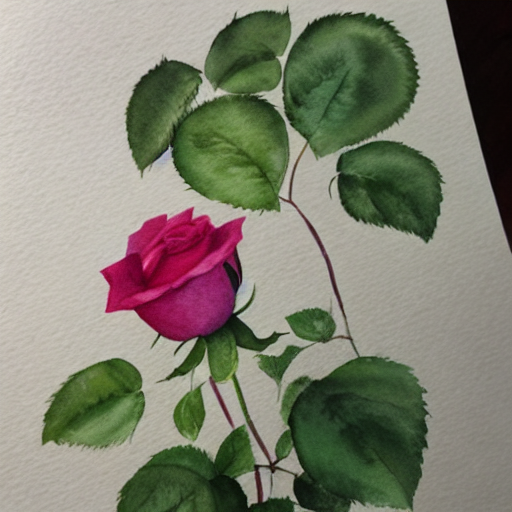

In [5]:
pipe("Watercolor illustration of a rose").images[0]

5.3.1 テキストエンコーダー

Stable Diffusion はノイズが加えられた画像が与えられると、クラスラベルなどの追加の手がかりをもとにノイズを除去した画像を生成しようとする。
この時、追加の手がかりとなる情報というのがテキストプロンプトになるというわけ。

このテキストを埋め込みとして渡す必要があるため、テキストエンコーダーを使う。
これをタイムステップやノイズを加えた潜在ベクトルとともに UNet に渡す。

これを実現するために Stable Diffusion は訓練済みの Transformer モデルを活用している。
すべてのトークンのベクトルを一つにまとめるだけでなく、トークンごとのベクトルを個別に保持し、Unet への条件付け情報として利用する。こうすることで、プロンプト全体の意味だけでなく、トークン個別の情報を活用できる。
これらの埋め込みは CLIP モデルの内部表現から抽出されることから、 **encoder隠れ状態**と呼ばれることがある。

実際にテキストをエンコードする仕組みを見ていく。

In [6]:
prompt = "A photograph of a puppy."

# テキストをトークンの列に変換する
text_input = pipe.tokenizer(
    prompt,
    return_tensors="pt"
)

# トークンと対応するIDを出力する
for t in text_input["input_ids"][0]:
  print(t, pipe.tokenizer.decoder.get(int(t)))

tensor(49406) <|startoftext|>
tensor(320) a</w>
tensor(8853) photograph</w>
tensor(539) of</w>
tensor(320) a</w>
tensor(6829) puppy</w>
tensor(269) .</w>
tensor(49407) <|endoftext|>


In [7]:
text_embeddings = pipe.text_encoder(text_input.input_ids.to(device))[0]
print("Text embeddings shape:", text_embeddings.shape)

Text embeddings shape: torch.Size([1, 8, 768])
